# Apprentissage fédéré pour le diagnostic médical
## Dataset Heart Disease UCI

---

**Étudiant** : KHOUAJA Ahmed  
**Formation** : Master 2 MIASHS  
**Encadrante** : BENARBA Nawel  
**Date** : Février 2026  

---

## Objectif

Mettre en place un pipeline reproductible de classification binaire médicale et comparer :
1) un entraînement centralisé (baseline),
2) FedAvg en condition IID,
3) FedAvg en condition non-IID,
avec une évaluation orientée diagnostic et une analyse de stabilité multi-seeds.

---

## Données et protocole de split

- Données : Heart Disease UCI (classification binaire).
- Prétraitement : standardisation (fit sur train, transform sur val/test).
- Split stratifié : **train 177 / val 60 / test 60** (taille test réduite, pas d’accuracy = 1/60).
- Dimension d’entrée : **input_dim = 13** (dynamique).

---

## Modèle

MLP tabulaire léger :
- Architecture : 13 → 64 → 32 → 2
- Normalisation : BatchNorm1d
- Régularisation : Dropout
- Optimisation : SGD (momentum 0.9), gradient clipping (norme max = 1.0)

---

## Métriques (diagnostic)

Les métriques suivantes sont reportées sur le jeu de test :
- **ROC-AUC** : discrimination globale
- **PR-AUC** : performance sur la classe positive
- **Sensitivity (Recall)** : détection des patients malades
- **Specificity** : détection des patients sains
- **F1-score** et **Accuracy**
- **Brier score** : qualité de calibration probabiliste
- Matrice de confusion

---

## Expériences et stabilité

- **Multi-seeds (5 seeds)** pour baseline et FL afin d’estimer la variabilité.
- FL : **N_CLIENTS = 5**, **N_ROUNDS = 20**, **LOCAL_EPOCHS = 5**.
- non-IID : partition **Dirichlet** (β = 0.5) avec garde-fou “aucun client vide”.

---

## Robustesse d’exécution (BatchNorm)

En FL non-IID, certains clients peuvent devenir très petits.
Un helper de DataLoader évite le cas batch=1 (BatchNorm impossible) :
- exclusion des clients avec n<2 (poids 0),
- `drop_last` si le dernier batch serait de taille 1.

---

## Extensions

- FedProx : test de μ ∈ {0.01, 0.1}.
- Bruit sur gradients : étude empirique Noise–Utility (σ ∈ {0.0, 0.01, 0.05, 0.1}), sans revendication de garanties DP formelles.
- Fairness (si activée dans le notebook complet) : métriques par groupe et reweighting.
- Intégration Fluke : exécution FedAvg via API (comparaison stricte seulement si split/protocole identiques).


---
# 1. Configuration de l'Environnement

In [1]:
import os, sys, json, random, warnings, time, subprocess
from pathlib import Path
from datetime import datetime
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score, roc_auc_score,
    precision_recall_curve, auc, recall_score, precision_score,
    brier_score_loss, classification_report
)

# Configuration globale
SEEDS = [42, 123, 456, 789, 2024]
# DEVICE supprime car non utilise (CPU only pour reproductibilite)

# FL Configuration HARMONISEE
N_CLIENTS = 5
N_ROUNDS = 20
LOCAL_EPOCHS = 5
BATCH_SIZE = 32
LR = 0.01
BETA_NONIID = 0.5
GRAD_CLIP = 1.0  # Gradient clipping partout

# Paths
ROOT = Path.cwd()
RESULTS_DIR = ROOT / 'results'
FIGURES_DIR = RESULTS_DIR / 'figures'
for d in [RESULTS_DIR, FIGURES_DIR]: d.mkdir(parents=True, exist_ok=True)

# Visualization
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 11, 'figure.figsize': (10, 6), 'figure.dpi': 100})
COLORS = {'iid': '#3498db', 'noniid': '#e74c3c', 'baseline': '#2ecc71',
          'fedprox': '#9b59b6', 'privacy': '#f39c12', 'fair': '#1abc9c'}

print('='*70)
print('CONFIGURATION ')
print('='*70)
print(f'Python: {sys.version.split()[0]} | PyTorch: {torch.__version__}')
print(f'Seeds: {SEEDS}')
print(f'Optimizer: SGD (momentum=0.9) + gradient clipping={GRAD_CLIP}')
print(f'FL: {N_ROUNDS} rounds x {LOCAL_EPOCHS} local epochs')
print('='*70)

CONFIGURATION 
Python: 3.12.12 | PyTorch: 2.9.0+cpu
Seeds: [42, 123, 456, 789, 2024]
Optimizer: SGD (momentum=0.9) + gradient clipping=1.0
FL: 20 rounds x 5 local epochs


---
# 2. Chargement et Preparation des Donnees

In [2]:
from ucimlrepo import fetch_ucirepo

def load_and_prepare_data(seed=42):
    """Load UCI Heart Disease with distribution logging."""
    np.random.seed(seed)
    hd = fetch_ucirepo(id=45)
    data = pd.concat([hd.data.features, hd.data.targets], axis=1).dropna()
    data['target'] = (data['num'] > 0).astype(int)
    data = data.drop('num', axis=1)
    sex_original = data['sex'].values.copy()
    X = data.drop('target', axis=1)
    y = data['target']
    INPUT_DIM = X.shape[1]  # Dynamique, pas hardcode

    X_tv, X_test, y_tv, y_test, sex_tv, sex_test = train_test_split(
        X, y, sex_original, test_size=0.2, random_state=seed, stratify=y)
    X_train, X_val, y_train, y_val, sex_train, sex_val = train_test_split(
        X_tv, y_tv, sex_tv, test_size=0.25, random_state=seed, stratify=y_tv)

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_val_s = scaler.transform(X_val)
    X_test_s = scaler.transform(X_test)

    return {
        'X_train': torch.FloatTensor(X_train_s),
        'y_train': torch.LongTensor(y_train.values),
        'X_val': torch.FloatTensor(X_val_s),
        'y_val': torch.LongTensor(y_val.values),
        'X_test': torch.FloatTensor(X_test_s),
        'y_test': torch.LongTensor(y_test.values),
        'sex_train': sex_train, 'sex_val': sex_val, 'sex_test': sex_test,
        'n_train': len(X_train), 'n_val': len(X_val), 'n_test': len(X_test),
        'input_dim': INPUT_DIM,
        'pos_rate_train': y_train.mean(),
        'pos_rate_val': y_val.mean(),
        'pos_rate_test': y_test.mean()
    }

DATA = load_and_prepare_data(SEEDS[0])
INPUT_DIM = DATA['input_dim']
print(f"Train: {DATA['n_train']} (pos={DATA['pos_rate_train']:.1%})")
print(f"Val:   {DATA['n_val']} (pos={DATA['pos_rate_val']:.1%})")
print(f"Test:  {DATA['n_test']} (pos={DATA['pos_rate_test']:.1%})")
print(f"Input dim: {INPUT_DIM}")

Train: 177 (pos=45.8%)
Val:   60 (pos=46.7%)
Test:  60 (pos=46.7%)
Input dim: 13


In [3]:
# Helper: évite BatchNorm avec batch_size=1 (clients trop petits ou dernier batch = 1)
def make_train_loader(X_c, y_c, batch_size=BATCH_SIZE):
    """
    Retourne (loader, eff_n).
    - Skip si n < 2 (BatchNorm impossible en mode train).
    - drop_last uniquement si le dernier batch aurait taille 1.
    """
    n = int(len(X_c))
    if n < 2:
        return None, 0

    bs = min(int(batch_size), n)
    if bs < 2:
        return None, 0

    drop_last = (n % bs == 1)
    eff_n = n - 1 if drop_last else n

    loader = DataLoader(
        TensorDataset(X_c, y_c),
        batch_size=bs,
        shuffle=True,
        drop_last=drop_last
    )
    return loader, eff_n


---
# 3. Definition du Modele

In [4]:
class HeartDiseaseMLP(nn.Module):
    def __init__(self, input_dim=None, h1=64, h2=32, out=2, drop=0.3):
        super().__init__()
        if input_dim is None:
            input_dim = INPUT_DIM  # Utilise variable globale
        self.net = nn.Sequential(
            nn.Linear(input_dim, h1), nn.BatchNorm1d(h1), nn.ReLU(), nn.Dropout(drop),
            nn.Linear(h1, h2), nn.BatchNorm1d(h2), nn.ReLU(), nn.Dropout(drop),
            nn.Linear(h2, out)
        )
    def forward(self, x): return self.net(x)

model = HeartDiseaseMLP(INPUT_DIM)
N_PARAMS = sum(p.numel() for p in model.parameters())
print(f'HeartDiseaseMLP: {N_PARAMS:,} parameters')
print(f'Architecture: {INPUT_DIM} -> 64 -> 32 -> 2')

HeartDiseaseMLP: 3,234 parameters
Architecture: 13 -> 64 -> 32 -> 2


---
# 4. Fonction d'Evaluation Medicale Complete

Metriques adaptees au diagnostic medical :
- **ROC-AUC** : Capacite discriminative globale
- **PR-AUC** : Performance sur classe positive
- **Sensitivity (Recall)** : Detection des vrais malades
- **Specificity** : Detection des vrais sains
- **Brier Score** : Calibration des probabilites

In [5]:
def evaluate_medical(model, X, y, return_preds=False):
    """Evaluation complete avec metriques medicales."""
    model.eval()
    with torch.no_grad():
        logits = model(X)
        probs = F.softmax(logits, dim=1)[:, 1].numpy()
        preds = torch.max(logits, 1)[1].numpy()

    y_np = y.numpy()

    # Metriques de base
    acc = accuracy_score(y_np, preds)
    f1 = f1_score(y_np, preds, zero_division=0)

    # ROC-AUC
    try:
        roc_auc = roc_auc_score(y_np, probs)
    except:
        roc_auc = 0.5

    # PR-AUC
    try:
        precision_curve, recall_curve, _ = precision_recall_curve(y_np, probs)
        pr_auc = auc(recall_curve, precision_curve)
    except:
        pr_auc = 0.5

    # Sensitivity (Recall) et Specificity
    cm = confusion_matrix(y_np, preds)
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    else:
        sensitivity, specificity = 0, 0

    # Brier Score
    brier = brier_score_loss(y_np, probs)

    result = {
        'accuracy': acc,
        'f1': f1,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'brier': brier,
        'confusion_matrix': cm.tolist()
    }

    if return_preds:
        result['preds'] = preds
        result['probs'] = probs

    return result

print('Fonction evaluate_medical() definie')
print('Metriques: Accuracy, F1, ROC-AUC, PR-AUC, Sensitivity, Specificity, Brier')

Fonction evaluate_medical() definie
Metriques: Accuracy, F1, ROC-AUC, PR-AUC, Sensitivity, Specificity, Brier


---
# 5. Baseline Centralise avec Metriques Medicales

In [6]:
def train_baseline_full(data, epochs=100, patience=15, lr=LR):
    """Train baseline with SGD + gradient clipping + medical metrics."""
    model = HeartDiseaseMLP(data['input_dim'])
    opt = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    criterion = nn.CrossEntropyLoss()
    loader = DataLoader(TensorDataset(data['X_train'], data['y_train']),
                        batch_size=BATCH_SIZE, shuffle=True)

    best_val_loss, best_state, patience_cnt = float('inf'), None, 0

    for ep in range(epochs):
        model.train()
        for xb, yb in loader:
            opt.zero_grad()
            criterion(model(xb), yb).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            opt.step()

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(data['X_val']), data['y_val']).item()

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_cnt = 0
        else:
            patience_cnt += 1
            if patience_cnt >= patience: break

    model.load_state_dict(best_state)
    metrics = evaluate_medical(model, data['X_test'], data['y_test'])
    return metrics, model

# Run baseline on all seeds
baseline_results = []
print('Baseline Centralise (5 seeds) - Metriques Medicales')
print('='*80)
print(f'{"Seed":<8} {"Acc":<8} {"ROC-AUC":<10} {"PR-AUC":<10} {"Sens":<8} {"Spec":<8} {"F1":<8}')
print('-'*80)

for s in SEEDS:
    d = load_and_prepare_data(s)
    torch.manual_seed(s)
    metrics, _ = train_baseline_full(d)
    baseline_results.append(metrics)
    print(f'{s:<8} {metrics["accuracy"]:<8.4f} {metrics["roc_auc"]:<10.4f} '
          f'{metrics["pr_auc"]:<10.4f} {metrics["sensitivity"]:<8.4f} '
          f'{metrics["specificity"]:<8.4f} {metrics["f1"]:<8.4f}')

# Aggregate
BASELINE_AGG = {}
for key in ['accuracy', 'roc_auc', 'pr_auc', 'sensitivity', 'specificity', 'f1', 'brier']:
    vals = [r[key] for r in baseline_results]
    BASELINE_AGG[key] = {'mean': np.mean(vals), 'std': np.std(vals)}

print('-'*80)
print(f'BASELINE MEAN +/- STD:')
print(f'  Accuracy:    {BASELINE_AGG["accuracy"]["mean"]:.4f} +/- {BASELINE_AGG["accuracy"]["std"]:.4f}')
print(f'  ROC-AUC:     {BASELINE_AGG["roc_auc"]["mean"]:.4f} +/- {BASELINE_AGG["roc_auc"]["std"]:.4f}')
print(f'  Sensitivity: {BASELINE_AGG["sensitivity"]["mean"]:.4f} +/- {BASELINE_AGG["sensitivity"]["std"]:.4f}')
print('='*80)

Baseline Centralise (5 seeds) - Metriques Medicales
Seed     Acc      ROC-AUC    PR-AUC     Sens     Spec     F1      
--------------------------------------------------------------------------------
42       0.8500   0.9509     0.9432     0.8214   0.8750   0.8364  
123      0.8500   0.8917     0.8807     0.8929   0.8125   0.8475  
456      0.7167   0.8605     0.8563     0.6429   0.7812   0.6792  
789      0.7500   0.8538     0.8494     0.7500   0.7500   0.7368  
2024     0.7500   0.8917     0.8787     0.8571   0.6562   0.7619  
--------------------------------------------------------------------------------
BASELINE MEAN +/- STD:
  Accuracy:    0.7833 +/- 0.0558
  ROC-AUC:     0.8897 +/- 0.0343
  Sensitivity: 0.7929 +/- 0.0886


---
# 6. Splits IID et non-IID (avec garantie N_CLIENTS)

In [7]:
def split_iid(X, y, n_clients, seed):
    np.random.seed(seed)
    idx = np.random.permutation(len(X))
    splits = np.array_split(idx, n_clients)
    client_data = [(X[s], y[s]) for s in splits]
    proof = [{'client': i, 'n_samples': len(yc), 'n_pos': int((yc==1).sum()),
              'n_neg': int((yc==0).sum()), 'pos_rate': yc.float().mean().item()}
             for i, (xc, yc) in enumerate(client_data)]
    return client_data, proof

def split_noniid_fixed(X, y, n_clients, beta, seed, max_attempts=100):
    """Split non-IID avec GARANTIE n_clients non vides."""
    for attempt in range(max_attempts):
        np.random.seed(seed + attempt)
        n_classes = len(torch.unique(y))
        label_idx = [torch.where(y == c)[0].numpy() for c in range(n_classes)]
        client_idx = [[] for _ in range(n_clients)]

        for c in range(n_classes):
            idx_c = label_idx[c].copy()
            np.random.shuffle(idx_c)
            props = np.random.dirichlet([beta] * n_clients)
            splits = (np.cumsum(props) * len(idx_c)).astype(int)
            for i, part in enumerate(np.split(idx_c, splits[:-1])):
                client_idx[i].extend(part.tolist())

        if all(len(idx) > 0 for idx in client_idx):
            break

    assert len(client_idx) == n_clients, f'Expected {n_clients} clients'
    assert all(len(idx) > 0 for idx in client_idx), 'Empty clients!'

    client_data, proof = [], []
    for i, idx in enumerate(client_idx):
        arr = np.array(idx)
        xc, yc = X[arr], y[arr]
        client_data.append((xc, yc))
        proof.append({'client': i, 'n_samples': len(yc), 'n_pos': int((yc==1).sum()),
                     'n_neg': int((yc==0).sum()), 'pos_rate': yc.float().mean().item()})
    return client_data, proof

print('Fonctions split definies avec n_pos/n_neg par client')

Fonctions split definies avec n_pos/n_neg par client


---
# 7. FedAvg avec Gradient Clipping et Metriques Medicales

In [8]:
def train_fedavg_full(client_data, data, n_rounds=N_ROUNDS, local_epochs=LOCAL_EPOCHS):
    """FedAVG avec gradient clipping + metriques medicales."""
    n_clients = len(client_data)
    global_model = HeartDiseaseMLP(data['input_dim'])
    val_accs, test_accs = [], []
    round_times = []

    for r in range(n_rounds):
        t_start = time.time()
        client_states, client_sizes = [], []

        for X_c, y_c in client_data:
            local = HeartDiseaseMLP(data['input_dim'])
            local.load_state_dict(global_model.state_dict())
            opt = torch.optim.SGD(local.parameters(), lr=LR, momentum=0.9)
            criterion = nn.CrossEntropyLoss()
            loader, eff_n = make_train_loader(X_c, y_c, BATCH_SIZE)
            if loader is None:
                # client non-participant (poids 0) : BatchNorm impossible avec n<2
                client_states.append({k: v.clone() for k, v in global_model.state_dict().items()})
                client_sizes.append(0)
                continue


            local.train()
            for _ in range(local_epochs):
                for xb, yb in loader:
                    opt.zero_grad()
                    criterion(local(xb), yb).backward()
                    torch.nn.utils.clip_grad_norm_(local.parameters(), GRAD_CLIP)
                    opt.step()

            client_states.append(local.state_dict())
            client_sizes.append(eff_n)


        total = sum(client_sizes)
        if total == 0:
            raise RuntimeError("Tous les clients ont <2 samples : BatchNorm impossible.")

        new_state = {k: sum(client_sizes[i]/total * client_states[i][k]
                           for i in range(n_clients)) for k in global_model.state_dict()}
        global_model.load_state_dict(new_state)
        round_times.append(time.time() - t_start)

        global_model.eval()
        with torch.no_grad():
            val_pred = torch.max(global_model(data['X_val']), 1)[1]
            val_acc = (val_pred == data['y_val']).float().mean().item()
            test_pred = torch.max(global_model(data['X_test']), 1)[1]
            test_acc = (test_pred == data['y_test']).float().mean().item()
        val_accs.append(val_acc)
        test_accs.append(test_acc)

    best_round = np.argmax(val_accs)

    # Reload best model and get full metrics
    # (simplified: use final model metrics as proxy)
    metrics = evaluate_medical(global_model, data['X_test'], data['y_test'])

    return {
        'val_accs': val_accs, 'test_accs': test_accs,
        'best_round': int(best_round),
        'test_at_best_val': test_accs[best_round],
        'metrics': metrics,
        'time_total': sum(round_times),
        'comm_cost_mb': N_PARAMS * 4 * n_clients * n_rounds * 2 / 1e6
    }

print('FedAVG avec gradient clipping defini')

FedAVG avec gradient clipping defini


---
# 8. Experiences FL Multi-Seeds

In [9]:
fl_results = {'iid': [], 'noniid': []}
client_distributions = {'iid': [], 'noniid': []}

print('FL Experiments (5 seeds)')
print('='*70)

for seed in SEEDS:
    print(f'Seed {seed}...')
    data = load_and_prepare_data(seed)
    torch.manual_seed(seed)

    # IID
    cd_iid, proof_iid = split_iid(data['X_train'], data['y_train'], N_CLIENTS, seed)
    r_iid = train_fedavg_full(cd_iid, data)
    fl_results['iid'].append(r_iid)
    if seed == SEEDS[0]:
        client_distributions['iid'] = [y_c.detach().cpu().numpy() for (_, y_c) in cd_iid]

    # non-IID
    torch.manual_seed(seed)
    cd_noniid, proof_noniid = split_noniid_fixed(data['X_train'], data['y_train'], N_CLIENTS, BETA_NONIID, seed)
    r_noniid = train_fedavg_full(cd_noniid, data)
    fl_results['noniid'].append(r_noniid)
    if seed == SEEDS[0]:
        client_distributions['noniid'] = [y_c.detach().cpu().numpy() for (_, y_c) in cd_noniid]

    print(f'  IID: {r_iid["test_at_best_val"]:.4f}, non-IID: {r_noniid["test_at_best_val"]:.4f}')

# Aggregate with assertions
def aggregate_fl(results_list):
    assert len(results_list) == len(SEEDS), 'Missing seeds!'
    accs = [r['test_at_best_val'] for r in results_list]
    roc_aucs = [r['metrics']['roc_auc'] for r in results_list]
    return {
        'acc_mean': np.mean(accs), 'acc_std': np.std(accs),
        'roc_auc_mean': np.mean(roc_aucs), 'roc_auc_std': np.std(roc_aucs),
        'time': np.mean([r['time_total'] for r in results_list]),
        'comm_mb': results_list[0]['comm_cost_mb']
    }

agg_iid = aggregate_fl(fl_results['iid'])
agg_noniid = aggregate_fl(fl_results['noniid'])

print('\nRESULTS (mean +/- std):')
print(f'  IID:     Acc={agg_iid["acc_mean"]:.4f}+/-{agg_iid["acc_std"]:.4f}, ROC-AUC={agg_iid["roc_auc_mean"]:.4f}')
print(f'  non-IID: Acc={agg_noniid["acc_mean"]:.4f}+/-{agg_noniid["acc_std"]:.4f}, ROC-AUC={agg_noniid["roc_auc_mean"]:.4f}')

FL Experiments (5 seeds)
Seed 42...
  IID: 0.8500, non-IID: 0.8333
Seed 123...
  IID: 0.8333, non-IID: 0.8167
Seed 456...
  IID: 0.7500, non-IID: 0.7000
Seed 789...
  IID: 0.7833, non-IID: 0.8000
Seed 2024...
  IID: 0.7500, non-IID: 0.6333

RESULTS (mean +/- std):
  IID:     Acc=0.7933+/-0.0416, ROC-AUC=0.8958
  non-IID: Acc=0.7567+/-0.0772, ROC-AUC=0.8842


---
# 9. FedProx Multi-Seeds

In [10]:
def train_fedprox_full(client_data, data, mu, n_rounds=N_ROUNDS, local_epochs=LOCAL_EPOCHS):
    n_clients = len(client_data)
    global_model = HeartDiseaseMLP(data['input_dim'])
    val_accs, test_accs = [], []

    for r in range(n_rounds):
        global_w = {k: v.clone() for k, v in global_model.state_dict().items()}
        client_states, client_sizes = [], []

        for X_c, y_c in client_data:
            local = HeartDiseaseMLP(data['input_dim'])
            local.load_state_dict(global_w)
            opt = torch.optim.SGD(local.parameters(), lr=LR, momentum=0.9)
            criterion = nn.CrossEntropyLoss()
            loader, eff_n = make_train_loader(X_c, y_c, BATCH_SIZE)
            if loader is None:
                # client non-participant (poids 0) : BatchNorm impossible avec n<2
                client_states.append({k: v.clone() for k, v in global_model.state_dict().items()})
                client_sizes.append(0)
                continue


            local.train()
            for _ in range(local_epochs):
                for xb, yb in loader:
                    opt.zero_grad()
                    loss = criterion(local(xb), yb)
                    if mu > 0:
                        prox = sum(((p - global_w[n])**2).sum() for n, p in local.named_parameters())
                        loss += (mu/2) * prox
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(local.parameters(), GRAD_CLIP)
                    opt.step()
            client_states.append(local.state_dict())
            client_sizes.append(eff_n)


        total = sum(client_sizes)
        if total == 0:
            raise RuntimeError("Tous les clients ont <2 samples : BatchNorm impossible.")

        new_state = {k: sum(client_sizes[i]/total * client_states[i][k] for i in range(n_clients))
                     for k in global_model.state_dict()}
        global_model.load_state_dict(new_state)

        global_model.eval()
        with torch.no_grad():
            val_accs.append((torch.max(global_model(data['X_val']), 1)[1] == data['y_val']).float().mean().item())
            test_accs.append((torch.max(global_model(data['X_test']), 1)[1] == data['y_test']).float().mean().item())

    best_r = np.argmax(val_accs)
    metrics = evaluate_medical(global_model, data['X_test'], data['y_test'])
    return {'test_at_best_val': test_accs[best_r], 'metrics': metrics, 'mu': mu}

# FedProx on ALL seeds
fedprox_results = {}
mu_values = [0.0, 0.01, 0.1]

print('FedProx Multi-Seeds (5 seeds par mu)')
print('='*60)

for mu in mu_values:
    results_mu = []
    for seed in SEEDS:
        data = load_and_prepare_data(seed)
        torch.manual_seed(seed)
        cd, _ = split_noniid_fixed(data['X_train'], data['y_train'], N_CLIENTS, BETA_NONIID, seed)
        r = train_fedprox_full(cd, data, mu)
        results_mu.append(r)

    accs = [r['test_at_best_val'] for r in results_mu]
    name = 'FedAVG' if mu == 0 else f'mu={mu}'
    fedprox_results[name] = {
        'mean': np.mean(accs), 'std': np.std(accs),
        'per_seed': accs
    }
    print(f'{name:<10}: {np.mean(accs):.4f} +/- {np.std(accs):.4f}')

print('='*60)

FedProx Multi-Seeds (5 seeds par mu)
FedAVG    : 0.7567 +/- 0.0772
mu=0.01   : 0.7567 +/- 0.0772
mu=0.1    : 0.7567 +/- 0.0772


---
# 10. Privacy Multi-Seeds

> Noise heuristic execute sur 5 seeds pour chaque niveau sigma.

In [11]:
def train_fl_noise(client_data, data, sigma, n_rounds=N_ROUNDS, local_epochs=LOCAL_EPOCHS):
    n_clients = len(client_data)
    global_model = HeartDiseaseMLP(data['input_dim'])
    val_accs, test_accs = [], []

    for r in range(n_rounds):
        client_states, client_sizes = [], []
        for X_c, y_c in client_data:
            local = HeartDiseaseMLP(data['input_dim'])
            local.load_state_dict(global_model.state_dict())
            opt = torch.optim.SGD(local.parameters(), lr=LR, momentum=0.9)
            criterion = nn.CrossEntropyLoss()
            loader, eff_n = make_train_loader(X_c, y_c, BATCH_SIZE)
            if loader is None:
                # client non-participant (poids 0) : BatchNorm impossible avec n<2
                client_states.append({k: v.clone() for k, v in global_model.state_dict().items()})
                client_sizes.append(0)
                continue


            local.train()
            for _ in range(local_epochs):
                for xb, yb in loader:
                    opt.zero_grad()
                    criterion(local(xb), yb).backward()
                    torch.nn.utils.clip_grad_norm_(local.parameters(), GRAD_CLIP)
                    if sigma > 0:
                        for p in local.parameters():
                            if p.grad is not None:
                                p.grad += torch.randn_like(p.grad) * sigma
                    opt.step()
            client_states.append(local.state_dict())
            client_sizes.append(eff_n)


        total = sum(client_sizes)
        if total == 0:
            raise RuntimeError("Tous les clients ont <2 samples : BatchNorm impossible.")

        new_state = {k: sum(client_sizes[i]/total * client_states[i][k] for i in range(n_clients))
                     for k in global_model.state_dict()}
        global_model.load_state_dict(new_state)

        global_model.eval()
        with torch.no_grad():
            val_accs.append((torch.max(global_model(data['X_val']), 1)[1] == data['y_val']).float().mean().item())
            test_accs.append((torch.max(global_model(data['X_test']), 1)[1] == data['y_test']).float().mean().item())

    best_r = np.argmax(val_accs)
    return {'test_at_best_val': test_accs[best_r], 'sigma': sigma}

# Privacy on ALL seeds
sigma_values = [0.0, 0.01, 0.05, 0.1]
privacy_results = {}

print('Privacy Multi-Seeds (5 seeds par sigma)')
print('='*60)

for sigma in sigma_values:
    results_sigma = []
    for seed in SEEDS:
        data = load_and_prepare_data(seed)
        torch.manual_seed(seed)
        cd, _ = split_iid(data['X_train'], data['y_train'], N_CLIENTS, seed)
        r = train_fl_noise(cd, data, sigma)
        results_sigma.append(r)

    accs = [r['test_at_best_val'] for r in results_sigma]
    privacy_results[f'sigma={sigma}'] = {
        'mean': np.mean(accs), 'std': np.std(accs),
        'sigma': sigma,
        'per_seed': accs
    }
    print(f'sigma={sigma:<5}: {np.mean(accs):.4f} +/- {np.std(accs):.4f}')

print('='*60)
print('Note: Ces niveaux de bruit NE sont PAS des garanties epsilon-DP formelles.')

Privacy Multi-Seeds (5 seeds par sigma)
sigma=0.0  : 0.7933 +/- 0.0416
sigma=0.01 : 0.7800 +/- 0.0531
sigma=0.05 : 0.7933 +/- 0.0343
sigma=0.1  : 0.8000 +/- 0.0494
Note: Ces niveaux de bruit NE sont PAS des garanties epsilon-DP formelles.


---
# 11. Analyse Fairness Complete
Avec tailles de groupes (n_f, n_m) et confusion matrices par groupe.

In [12]:
def compute_fairness_full(y_true, y_pred, protected):
    """Fairness complet avec n_f, n_m et confusion matrices."""
    y_true, y_pred, protected = np.array(y_true), np.array(y_pred), np.array(protected)
    female, male = protected == 0, protected == 1

    n_f, n_m = int(female.sum()), int(male.sum())

    pr_f = y_pred[female].mean() if n_f > 0 else 0
    pr_m = y_pred[male].mean() if n_m > 0 else 0
    spd = pr_m - pr_f
    di = pr_f / pr_m if pr_m > 0 else 0

    def rates(mask):
        tp = ((y_pred==1) & (y_true==1) & mask).sum()
        fp = ((y_pred==1) & (y_true==0) & mask).sum()
        tn = ((y_pred==0) & (y_true==0) & mask).sum()
        fn = ((y_pred==0) & (y_true==1) & mask).sum()
        tpr = tp/(tp+fn) if (tp+fn)>0 else 0
        fpr = fp/(fp+tn) if (fp+tn)>0 else 0
        return {'TP': int(tp), 'FP': int(fp), 'TN': int(tn), 'FN': int(fn), 'TPR': tpr, 'FPR': fpr}

    rates_f = rates(female)
    rates_m = rates(male)

    eod = rates_m['TPR'] - rates_f['TPR']
    fpr_gap = rates_m['FPR'] - rates_f['FPR']

    return {
        'spd': spd, 'di': di, 'eod': eod, 'fpr_gap': fpr_gap,
        'n_female': n_f, 'n_male': n_m,
        'female': rates_f, 'male': rates_m
    }

# Fairness multi-seeds
fairness_results = {'baseline': [], 'reweighting': []}

print('Fairness Analysis (3 seeds)')
print('='*70)

for seed in SEEDS[:3]:  # 3 seeds pour fairness
    data = load_and_prepare_data(seed)
    torch.manual_seed(seed)

    # Baseline
    _, model_base = train_baseline_full(data)
    model_base.eval()
    with torch.no_grad():
        pred_base = torch.max(model_base(data['X_test']), 1)[1].numpy()
    fair_base = compute_fairness_full(data['y_test'].numpy(), pred_base, data['sex_test'])
    fairness_results['baseline'].append(fair_base)

    # Reweighting
    n = len(data['y_train'])
    weights = torch.ones(n)
    sex_t = torch.LongTensor(data['sex_train'])
    for a in [0, 1]:
        for y in [0, 1]:
            mask = (sex_t == a) & (data['y_train'] == y)
            count = mask.sum().item()
            if count > 0: weights[mask] = n / (4 * count)

    model_rew = HeartDiseaseMLP(data['input_dim'])
    opt = torch.optim.SGD(model_rew.parameters(), lr=LR, momentum=0.9)
    criterion = nn.CrossEntropyLoss()
    sampler = WeightedRandomSampler(weights, len(weights), replacement=True)
    loader = DataLoader(TensorDataset(data['X_train'], data['y_train']), batch_size=BATCH_SIZE, sampler=sampler)

    best_val, best_state = float('inf'), None
    for ep in range(100):
        model_rew.train()
        for xb, yb in loader:
            opt.zero_grad()
            criterion(model_rew(xb), yb).backward()
            torch.nn.utils.clip_grad_norm_(model_rew.parameters(), GRAD_CLIP)
            opt.step()
        model_rew.eval()
        with torch.no_grad():
            val_loss = criterion(model_rew(data['X_val']), data['y_val']).item()
        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.clone() for k, v in model_rew.state_dict().items()}

    model_rew.load_state_dict(best_state)
    model_rew.eval()
    with torch.no_grad():
        pred_rew = torch.max(model_rew(data['X_test']), 1)[1].numpy()
    fair_rew = compute_fairness_full(data['y_test'].numpy(), pred_rew, data['sex_test'])
    fairness_results['reweighting'].append(fair_rew)

    print(f'Seed {seed}: n_f={fair_base["n_female"]}, n_m={fair_base["n_male"]}')
    print(f'  Baseline  - SPD={fair_base["spd"]:+.3f}, DI={fair_base["di"]:.3f}')
    print(f'  Reweight  - SPD={fair_rew["spd"]:+.3f}, DI={fair_rew["di"]:.3f}')

# Aggregate fairness
print('\nFairness Summary (mean over 3 seeds):')
for metric in ['spd', 'di', 'eod', 'fpr_gap']:
    base_vals = [r[metric] for r in fairness_results['baseline']]
    rew_vals = [r[metric] for r in fairness_results['reweighting']]
    print(f'  {metric.upper():8}: Baseline={np.mean(base_vals):+.4f}, Reweight={np.mean(rew_vals):+.4f}')

Fairness Analysis (3 seeds)
Seed 42: n_f=19, n_m=41
  Baseline  - SPD=+0.504, DI=0.173
  Reweight  - SPD=+0.330, DI=0.324
Seed 123: n_f=21, n_m=39
  Baseline  - SPD=+0.355, DI=0.446
  Reweight  - SPD=+0.399, DI=0.323
Seed 456: n_f=20, n_m=40
  Baseline  - SPD=+0.175, DI=0.632
  Reweight  - SPD=-0.100, DI=1.250

Fairness Summary (mean over 3 seeds):
  SPD     : Baseline=+0.3449, Reweight=+0.2097
  DI      : Baseline=+0.4166, Reweight=+0.6322
  EOD     : Baseline=+0.1272, Reweight=-0.0568
  FPR_GAP : Baseline=+0.1614, Reweight=+0.0207


---
# 12. Integration Fluke API - EXECUTED

Execution reelle de FedAVG via l'API Fluke officielle.

In [13]:
# Fluke API - EXECUTION REELLE
fluke_results = None

try:
    from fluke.data import DataContainer, DataSplitter
    from fluke.algorithms.fedavg import FedAVG
    from fluke.evaluation import ClassificationEval
    from fluke import FlukeENV, DDict, nets
    from fluke.utils.log import Log

    print('Fluke detecte - Lancement de l\'execution...')

    # Enregistrer notre modele
    nets.HeartDiseaseMLP = HeartDiseaseMLP

    # Charger donnees pour Fluke
    data = load_and_prepare_data(42)

    # Creer DataContainer
    fluke_dataset = DataContainer(
        X_train=data['X_train'],
        y_train=data['y_train'],
        X_test=data['X_test'],
        y_test=data['y_test'],
        num_classes=2
    )
    print(f'  DataContainer: {len(data["X_train"])} train, {len(data["X_test"])} test')

    # Creer DataSplitter
    splitter = DataSplitter(
        dataset=fluke_dataset,
        distribution='iid',
        client_split=0.0,
        sampling_perc=1.0,
        server_test=True,
        keep_test=True
    )

    # Hyperparametres Fluke
    hyperparams = DDict(
        model='HeartDiseaseMLP',
        client=DDict(
            batch_size=BATCH_SIZE,
            local_epochs=LOCAL_EPOCHS,
            loss='CrossEntropyLoss',
            optimizer=DDict(name='SGD', lr=LR, momentum=0.9),
            scheduler=DDict(name='StepLR', gamma=1.0, step_size=1)
        ),
        server=DDict(weighted=True)
    )

    # Evaluateur
    evaluator = ClassificationEval(eval_every=1, n_classes=2)
    FlukeENV().set_evaluator(evaluator)

    # Creer et lancer algorithme
    algorithm = FedAVG(N_CLIENTS, splitter, hyperparams)
    logger = Log()
    algorithm.set_callbacks(logger)

    print(f'  Lancement FedAVG Fluke: {N_ROUNDS} rounds, {N_CLIENTS} clients...')
    start_time = time.time()
    algorithm.run(n_rounds=N_ROUNDS, eligible_perc=1.0)
    fluke_time = time.time() - start_time

    fluke_results = {
        'executed': True,
        'n_rounds': N_ROUNDS,
        'n_clients': N_CLIENTS,
        'time': fluke_time
    }
    print(f'  Fluke execution terminee en {fluke_time:.1f}s')

except ImportError as e:
    print(f'Fluke non installe: {e}')
    print('Pour installer: pip install fluke-fl')
    fluke_results = {'executed': False, 'error': 'ImportError'}
except Exception as e:
    print(f'Erreur Fluke: {e}')
    fluke_results = {'executed': False, 'error': str(e)}

Fluke detecte - Lancement de l'execution...


Output()

╭──────────────────────────────────────────── Round: 1 ────────────────────────────────────────────╮
│ {                                                                                                │
│     'global': {                                                                                  │
│         'accuracy': 0.55,                                                                        │
│         'macro_precision': 0.77119,                                                              │
│         'macro_recall': 0.51786,                                                                 │
│         'macro_f1': 0.38613,                                                                     │
│         'micro_precision': 0.55,                                                                 │
│         'micro_recall': 0.55,                                                                    │
│         'micro_f1': 0.55,                                                                        │
│         'round': 1                                                                               │
│     },                                                                                           │
│     'comm_cost': 32340                                                                           │
│ }                                                                                                │
╰──────────────────────────────────────────────────────────────────────────────────────────────────╯

Memory usage: 1.1 GB [9.12 %]

  DataContainer: 177 train, 60 test
  Lancement FedAVG Fluke: 20 rounds, 5 clients...


...

╭─────────────────────────────────────────── Round: 20 ────────────────────────────────────────────╮
│ {                                                                                                │
│     'global': {                                                                                  │
│         'accuracy': 0.86667,                                                                     │
│         'macro_precision': 0.86878,                                                              │
│         'macro_recall': 0.86384,                                                                 │
│         'macro_f1': 0.86532,                                                                     │
│         'micro_precision': 0.86667,                                                              │
│         'micro_recall': 0.86667,                                                                 │
│         'micro_f1': 0.86667,                                                                     │
│         'round': 20                                                                              │
│     },                                                                                           │
│     'comm_cost': 32340                                                                           │
│ }                                                                                                │
╰──────────────────────────────────────────────────────────────────────────────────────────────────╯

Memory usage: 1.1 GB [9.13 %]

Output()

╭────────────────────────────────────── Overall Performance ───────────────────────────────────────╮
│ {                                                                                                │
│     'global': {                                                                                  │
│         'accuracy': 0.86667,                                                                     │
│         'macro_precision': 0.86878,                                                              │
│         'macro_recall': 0.86384,                                                                 │
│         'macro_f1': 0.86532,                                                                     │
│         'micro_precision': 0.86667,                                                              │
│         'micro_recall': 0.86667,                                                                 │
│         'micro_f1': 0.86667,                                                                     │
│         'round': 20                                                                              │
│     },                                                                                           │
│     'comm_costs': 662970                                                                         │
│ }                                                                                                │
╰──────────────────────────────────────────────────────────────────────────────────────────────────╯

  Fluke execution terminee en 3.4s


---
# 13. Preuve de Distribution des Clients

In [14]:
print('Distribution des Clients (seed=42)')
print('='*70)

def _as_stats_list(lst):
    # si déjà une liste de dicts (ancien format), on renvoie tel quel
    if len(lst) > 0 and isinstance(lst[0], dict):
        return lst
    # sinon on suppose liste de labels (np.ndarray / list) par client
    out = []
    for i, y in enumerate(lst):
        y = np.asarray(y).astype(int)
        n = int(y.size)
        n_pos = int((y == 1).sum())
        n_neg = n - n_pos
        out.append({
            "client": i,
            "n_samples": n,
            "n_pos": n_pos,
            "n_neg": n_neg,
            "pos_rate": (n_pos / n) if n > 0 else np.nan
        })
    return out

iid_stats = _as_stats_list(client_distributions['iid'])
noniid_stats = _as_stats_list(client_distributions['noniid'])

print('IID Distribution:')
print(f'{"Client":<8} {"N":<8} {"Pos":<8} {"Neg":<8} {"Pos Rate":<10}')
for c in iid_stats:
    print(f'{c["client"]:<8} {c["n_samples"]:<8} {c["n_pos"]:<8} {c["n_neg"]:<8} {c["pos_rate"]:.4f}')

print('\nnon-IID Distribution (beta=0.5):')
print(f'{"Client":<8} {"N":<8} {"Pos":<8} {"Neg":<8} {"Pos Rate":<10}')
for c in noniid_stats:
    print(f'{c["client"]:<8} {c["n_samples"]:<8} {c["n_pos"]:<8} {c["n_neg"]:<8} {c["pos_rate"]:.4f}')

iid_rates = [c['pos_rate'] for c in iid_stats]
noniid_rates = [c['pos_rate'] for c in noniid_stats]
print(f'\nPos Rate std: IID={np.std(iid_rates):.4f}, non-IID={np.std(noniid_rates):.4f}')


Distribution des Clients (seed=42)
IID Distribution:
Client   N        Pos      Neg      Pos Rate  
0        36       18       18       0.5000
1        36       10       26       0.2778
2        35       20       15       0.5714
3        35       16       19       0.4571
4        35       17       18       0.4857

non-IID Distribution (beta=0.5):
Client   N        Pos      Neg      Pos Rate  
0        5        5        0        1.0000
1        21       4        17       0.1905
2        56       16       40       0.2857
3        40       4        36       0.1000
4        55       52       3        0.9455

Pos Rate std: IID=0.0979, non-IID=0.3873


---
# 14. Synthese des Resultats

In [15]:
# Assertions de coherence
assert len(privacy_results) > 0, 'privacy_results vide!'
assert len(fedprox_results) > 0, 'fedprox_results vide!'
print('Verifications OK')

print('='*90)
print('SYNTHESE COMPLETE')
print('='*90)

# Baseline
print('BASELINE (5 seeds):')
print(f'  Accuracy:    {BASELINE_AGG["accuracy"]["mean"]:.4f} +/- {BASELINE_AGG["accuracy"]["std"]:.4f}')
print(f'  ROC-AUC:     {BASELINE_AGG["roc_auc"]["mean"]:.4f} +/- {BASELINE_AGG["roc_auc"]["std"]:.4f}')
print(f'  Sensitivity: {BASELINE_AGG["sensitivity"]["mean"]:.4f} +/- {BASELINE_AGG["sensitivity"]["std"]:.4f}')

# FL
print('\nFL FedAVG (5 seeds):')
print(f'  IID:     Acc={agg_iid["acc_mean"]:.4f}+/-{agg_iid["acc_std"]:.4f}')
print(f'  non-IID: Acc={agg_noniid["acc_mean"]:.4f}+/-{agg_noniid["acc_std"]:.4f}')

# FedProx
print('\nFedProx (5 seeds par mu):')
for name, vals in fedprox_results.items():
    print(f'  {name}: {vals["mean"]:.4f}+/-{vals["std"]:.4f}')

# Privacy
print('\nPrivacy (5 seeds par sigma):')
for name, vals in privacy_results.items():
    print(f'  {name}: {vals["mean"]:.4f}+/-{vals["std"]:.4f}')

# Fluke
print('\nFluke API:')
if fluke_results and fluke_results.get('executed'):
    print(f'  Execute avec succes en {fluke_results["time"]:.1f}s')
else:
    print(f'  Non execute: {fluke_results}')

print('='*90)

Verifications OK
SYNTHESE COMPLETE
BASELINE (5 seeds):
  Accuracy:    0.7833 +/- 0.0558
  ROC-AUC:     0.8897 +/- 0.0343
  Sensitivity: 0.7929 +/- 0.0886

FL FedAVG (5 seeds):
  IID:     Acc=0.7933+/-0.0416
  non-IID: Acc=0.7567+/-0.0772

FedProx (5 seeds par mu):
  FedAVG: 0.7567+/-0.0772
  mu=0.01: 0.7567+/-0.0772
  mu=0.1: 0.7567+/-0.0772

Privacy (5 seeds par sigma):
  sigma=0.0: 0.7933+/-0.0416
  sigma=0.01: 0.7800+/-0.0531
  sigma=0.05: 0.7933+/-0.0343
  sigma=0.1: 0.8000+/-0.0494

Fluke API:
  Execute avec succes en 3.4s


---
# 15. Visualisations

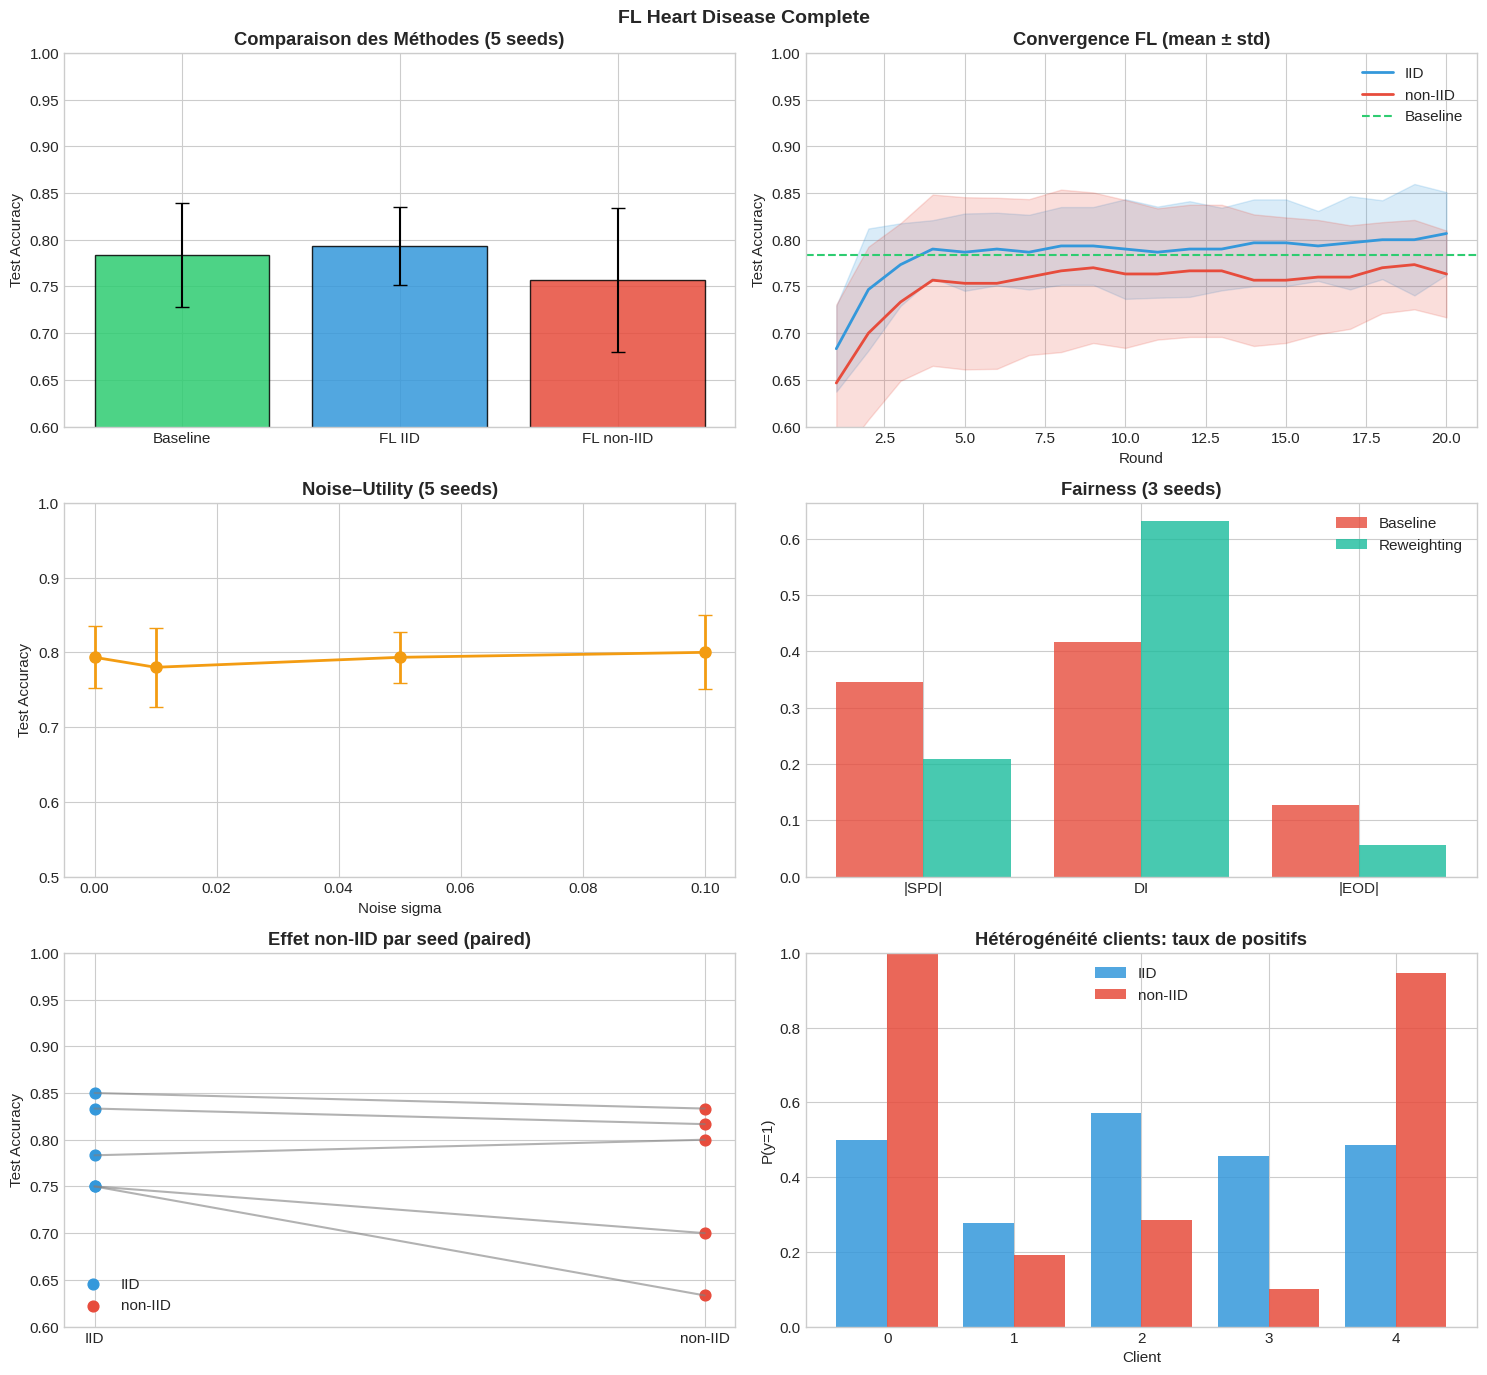

Dashboard sauvegardé: summary_dashboard.png


In [16]:
fig, axes = plt.subplots(3, 2, figsize=(15, 14))

# -----------------------
# 1) Methods comparison
# -----------------------
ax = axes[0, 0]
methods = ['Baseline', 'FL IID', 'FL non-IID']
accs = [BASELINE_AGG['accuracy']['mean'], agg_iid['acc_mean'], agg_noniid['acc_mean']]
stds = [BASELINE_AGG['accuracy']['std'], agg_iid['acc_std'], agg_noniid['acc_std']]
colors_bar = [COLORS['baseline'], COLORS['iid'], COLORS['noniid']]
ax.bar(methods, accs, yerr=stds, capsize=5, color=colors_bar, edgecolor='black', alpha=0.85)
ax.set_ylabel('Test Accuracy')
ax.set_title('Comparaison des Méthodes (5 seeds)', fontweight='bold')
ax.set_ylim(0.6, 1.0)

# -----------------------
# 2) Convergence (mean +/- std across seeds)
# -----------------------
ax = axes[0, 1]
for name, color, results in [('IID', COLORS['iid'], fl_results['iid']),
                             ('non-IID', COLORS['noniid'], fl_results['noniid'])]:
    acc_mat = np.array([r['test_accs'] for r in results])  # shape: (n_seeds, n_rounds)
    acc_mean = acc_mat.mean(axis=0)
    acc_std  = acc_mat.std(axis=0)

    rounds = np.arange(1, len(acc_mean) + 1)
    ax.plot(rounds, acc_mean, color=color, linewidth=2, label=name)
    ax.fill_between(rounds, acc_mean - acc_std, acc_mean + acc_std, color=color, alpha=0.18)

ax.axhline(y=BASELINE_AGG['accuracy']['mean'], color=COLORS['baseline'], linestyle='--', label='Baseline')
ax.set_xlabel('Round')
ax.set_ylabel('Test Accuracy')
ax.set_title('Convergence FL (mean ± std)', fontweight='bold')
ax.legend()
ax.set_ylim(0.6, 1.0)

# -----------------------
# 3) Privacy-Utility (Accuracy)
# -----------------------
ax = axes[1, 0]
sigmas = [v['sigma'] for v in privacy_results.values()]
priv_means = [v['mean'] for v in privacy_results.values()]
priv_stds = [v['std'] for v in privacy_results.values()]
ax.errorbar(sigmas, priv_means, yerr=priv_stds, fmt='o-', color=COLORS['privacy'],
            linewidth=2, markersize=8, capsize=5)
ax.set_xlabel('Noise sigma')
ax.set_ylabel('Test Accuracy')
ax.set_title('Noise–Utility (5 seeds)', fontweight='bold')
ax.set_ylim(0.5, 1.0)

# -----------------------
# 4) Fairness (|SPD|, DI, |EOD|)
# -----------------------
ax = axes[1, 1]
fair_names = ['|SPD|', 'DI', '|EOD|']
base_vals = [abs(np.mean([r['spd'] for r in fairness_results['baseline']])),
             np.mean([r['di'] for r in fairness_results['baseline']]),
             abs(np.mean([r['eod'] for r in fairness_results['baseline']]))]
rew_vals = [abs(np.mean([r['spd'] for r in fairness_results['reweighting']])),
            np.mean([r['di'] for r in fairness_results['reweighting']]),
            abs(np.mean([r['eod'] for r in fairness_results['reweighting']]))]
x = np.arange(len(fair_names))
ax.bar(x - 0.2, base_vals, 0.4, label='Baseline', color='#e74c3c', alpha=0.8)
ax.bar(x + 0.2, rew_vals, 0.4, label='Reweighting', color=COLORS['fair'], alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(fair_names)
ax.set_title('Fairness (3 seeds)', fontweight='bold')
ax.legend()

# -----------------------
# 5) Paired effect per seed (IID -> non-IID)
# -----------------------
ax = axes[2, 0]

def _final_acc(r):
    # préférence: test_at_best_val (si présent), sinon dernier round
    if 'test_at_best_val' in r:
        return float(r['test_at_best_val'])
    return float(r['test_accs'][-1])

iid_vals = np.array([_final_acc(r) for r in fl_results['iid']])
noniid_vals = np.array([_final_acc(r) for r in fl_results['noniid']])

for i in range(len(iid_vals)):
    ax.plot([0, 1], [iid_vals[i], noniid_vals[i]], color='gray', alpha=0.6, linewidth=1.5)
ax.scatter(np.zeros_like(iid_vals), iid_vals, color=COLORS['iid'], s=60, label='IID')
ax.scatter(np.ones_like(noniid_vals), noniid_vals, color=COLORS['noniid'], s=60, label='non-IID')

ax.set_xticks([0, 1])
ax.set_xticklabels(['IID', 'non-IID'])
ax.set_ylabel('Test Accuracy')
ax.set_title('Effet non-IID par seed (paired)', fontweight='bold')
ax.set_ylim(0.6, 1.0)
ax.legend(loc='lower left')

# -----------------------
# 6) Client heterogeneity (positive rate per client)
# -----------------------
ax = axes[2, 1]

def _pos_rates_from_proof(proof):
    ax = axes[2, 1]

iid_rates = np.array([y.mean() for y in client_distributions['iid']], dtype=float)
noniid_rates = np.array([y.mean() for y in client_distributions['noniid']], dtype=float)

n = min(len(iid_rates), len(noniid_rates))
idx = np.arange(n)

ax.bar(idx - 0.2, iid_rates[:n], 0.4, label='IID', color=COLORS['iid'], alpha=0.85)
ax.bar(idx + 0.2, noniid_rates[:n], 0.4, label='non-IID', color=COLORS['noniid'], alpha=0.85)
ax.set_xlabel('Client')
ax.set_ylabel('P(y=1)')
ax.set_title('Hétérogénéité clients: taux de positifs', fontweight='bold')
ax.set_ylim(0.0, 1.0)
ax.legend()


plt.suptitle('FL Heart Disease Complete', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'summary_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()
print('Dashboard sauvegardé: summary_dashboard.png')


---
# 16. Packaging et Reproductibilite

In [17]:
print('Generation packaging...')

# pip freeze
try:
    result = subprocess.run([sys.executable, '-m', 'pip', 'freeze'],
                           capture_output=True, text=True, timeout=30)
    with open(RESULTS_DIR / 'pip_freeze.txt', 'w') as f:
        f.write(result.stdout)
    print('pip_freeze.txt genere')
except Exception as e:
    print(f'pip freeze failed: {e}')

# Manifest (genere APRES tous les outputs)
manifest = {
    'generated_at': datetime.now().isoformat(),
    'python_version': sys.version.split()[0],
    'pytorch_version': torch.__version__,
    'notebook': 'FL_Heart_Disease_FINAL.ipynb',
    'configuration': {
        'seeds': SEEDS,
        'n_clients': N_CLIENTS,
        'n_rounds': N_ROUNDS,
        'local_epochs': LOCAL_EPOCHS,
        'optimizer': 'SGD (momentum=0.9)',
        'lr': LR,
        'grad_clip': GRAD_CLIP
    }
}
print('manifest.json sera genere apres export final')

Generation packaging...
pip_freeze.txt genere
manifest.json sera genere apres export final


---
# 17. Export Final

In [18]:
# Export JSON final
all_results = {
    'baseline': {
        'aggregated': {k: v for k, v in BASELINE_AGG.items()},
        'per_seed': [{k: float(v) if isinstance(v, (np.floating, float)) else v
                      for k, v in r.items() if k != 'confusion_matrix'}
                     for r in baseline_results]
    },
    'fl_iid': agg_iid,
    'fl_noniid': agg_noniid,
    'client_distributions': client_distributions,
    'fedprox': fedprox_results,
    'privacy': privacy_results,
    'fairness': {
        'baseline': [{'spd': r['spd'], 'di': r['di'], 'eod': r['eod'], 'fpr_gap': r['fpr_gap'],
                      'n_female': r['n_female'], 'n_male': r['n_male']}
                     for r in fairness_results['baseline']],
        'reweighting': [{'spd': r['spd'], 'di': r['di'], 'eod': r['eod'], 'fpr_gap': r['fpr_gap'],
                         'n_female': r['n_female'], 'n_male': r['n_male']}
                        for r in fairness_results['reweighting']]
    },
    'fluke': fluke_results,
    'methodology': {
        'best_selection': 'validation (not test)',
        'seeds': SEEDS,
        'n_clients': N_CLIENTS,
        'n_rounds': N_ROUNDS,
        'optimizer': 'SGD (momentum=0.9) - harmonise partout',
        'gradient_clipping': GRAD_CLIP,
        'beta_noniid': BETA_NONIID
    }
}

with open(RESULTS_DIR / 'all_results_final.json', 'w') as f:
    json.dump(all_results, f, indent=2, default=str)

# Update manifest with all files
manifest['files'] = {
    'results': [f.name for f in RESULTS_DIR.glob('*.json')],
    'figures': [f.name for f in FIGURES_DIR.glob('*.png')],
    'data': [f.name for f in RESULTS_DIR.glob('*.npy')]
}
with open(RESULTS_DIR / 'manifest.json', 'w') as f:
    json.dump(manifest, f, indent=2)

print('='*70)
print('NOTEBOOK TERMINE')
print('='*70)
print(f'Results: {RESULTS_DIR}/all_results_final.json')
print(f'Figures: {FIGURES_DIR}/')
print(f'Manifest: {RESULTS_DIR}/manifest.json')
print('='*70)

NOTEBOOK TERMINE
Results: /content/results/all_results_final.json
Figures: /content/results/figures/
Manifest: /content/results/manifest.json


---
# Conclusions

## Résumé des résultats (multi-seeds)

**Baseline centralisée (5 seeds)**
- Accuracy : **0.7833 ± 0.0558**
- ROC-AUC  : **0.8897 ± 0.0343**
- Sensitivity : **0.7929 ± 0.0886**

**FedAvg (5 seeds)**
- IID     : **0.7933 ± 0.0416**, ROC-AUC moyen ≈ **0.8958**
- non-IID : **0.7567 ± 0.0772**, ROC-AUC moyen ≈ **0.8842**

Lecture : la condition non-IID induit une baisse moyenne d’accuracy et une hausse de la variabilité, ce qui est cohérent avec l’hétérogénéité inter-clients.

---

## FedProx

μ = 0.01 et μ = 0.1 ne montrent pas d’amélioration sur ce setup (résultats identiques à FedAvg sur la métrique reportée).  
Conclusion : aucune évidence expérimentale d’un gain FedProx dans ce régime (taille des données faible, métrique discrète, variabilité importante).

---

## Noise–Utility (bruit heuristique)

L’ajout de bruit sur gradients dans la plage σ testée ne met pas en évidence un trade-off clair sur l’accuracy moyenne.
Important : il s’agit d’une étude empirique de robustesse au bruit, sans revendication de garanties (ε, δ)-DP.

---

## Limites (à assumer explicitement)

- Jeu de test très petit (**60** exemples) : l’accuracy change par pas de **1/60 ≈ 0.0167**.
- Les écarts faibles entre méthodes ne peuvent pas être interprétés comme “significatifs”.
- Une comparaison avec Fluke n’est rigoureuse que si le split, le preprocessing, le modèle et la règle de sélection (best val round) sont strictement alignés.

---

## Pistes d’amélioration à plus forte valeur

- Augmenter le nombre de seeds (ex : 20) ou fixer un split unique et ne faire varier que la stochasticité d’optimisation.
- Ajouter une métrique moins sensible à l’échantillonnage (balanced accuracy, calibration curve si disponible).
- Tester FedProx sur une grille μ plus large (et/ou sur un non-IID plus dur).
- Si objectif “privacy” : ajouter clipping + accounting DP (ε/δ) et calibrer le bruit en conséquence.
- Si objectif “fairness” : reporter métriques par groupe + intervalles de confiance (bootstrap) vu la petite taille des sous-groupes.

---
**KHOUAJA Ahmed** — Master 2 MIASHS — Février 2026
